<a href="https://colab.research.google.com/github/Roopalsood/Pharmaceutical-Sales-Analysis-using-Python-SQL-Power-BI/blob/main/pharma_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pharmaceutical Sales Analysis using Python, SQL & Power BI

Project Overview

This project analyzes pharmaceutical sales data across hourly, daily, weekly, and monthly intervals using Python, SQLite, SQL, and Power BI. The objective is to clean and transform raw sales data, perform exploratory and SQL-based analysis, and generate business insights through interactive dashboards

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

**Loading Datasets from GitHub**

In [2]:
sales_daily_url = 'https://raw.githubusercontent.com/Roopalsood/Pharmaceutical-Sales-Analysis-using-Python-SQL-Power-BI/refs/heads/main/saleshourly.csv'
sales_hourly_url = 'https://raw.githubusercontent.com/Roopalsood/Pharmaceutical-Sales-Analysis-using-Python-SQL-Power-BI/refs/heads/main/saleshourly.csv'
sales_weekly_url = 'https://raw.githubusercontent.com/Roopalsood/Pharmaceutical-Sales-Analysis-using-Python-SQL-Power-BI/refs/heads/main/salesweekly.csv'
sales_monthly_url = 'https://raw.githubusercontent.com/Roopalsood/Pharmaceutical-Sales-Analysis-using-Python-SQL-Power-BI/refs/heads/main/salesmonthly.csv'

In [3]:
sales_daily = pd.read_csv(sales_daily_url)
sales_hourly = pd.read_csv(sales_hourly_url)
sales_weekly = pd.read_csv(sales_weekly_url)
sales_monthly = pd.read_csv(sales_monthly_url)

print('Daily Dataset Shape:', sales_daily.shape)
print('Hourly Dataset Shape:', sales_hourly.shape)
print('Weekly Dataset Shape:', sales_weekly.shape)
print('Monthly Dataset Shape:', sales_monthly.shape)

Daily Dataset Shape: (50532, 13)
Hourly Dataset Shape: (50532, 13)
Weekly Dataset Shape: (302, 9)
Monthly Dataset Shape: (70, 9)


In [4]:
sales_monthly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [5]:
sales_hourly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [6]:
sales_weekly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,1/5/2014,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,1/12/2014,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2/2/2014,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [7]:
sales_monthly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [8]:
sales_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  object 
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02BA         50532 non-null  float64
 4   N02BE         50532 non-null  float64
 5   N05B          50532 non-null  float64
 6   N05C          50532 non-null  float64
 7   R03           50532 non-null  float64
 8   R06           50532 non-null  float64
 9   Year          50532 non-null  int64  
 10  Month         50532 non-null  int64  
 11  Hour          50532 non-null  int64  
 12  Weekday Name  50532 non-null  object 
dtypes: float64(8), int64(3), object(2)
memory usage: 5.0+ MB


In [9]:
sales_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  object 
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02BA         50532 non-null  float64
 4   N02BE         50532 non-null  float64
 5   N05B          50532 non-null  float64
 6   N05C          50532 non-null  float64
 7   R03           50532 non-null  float64
 8   R06           50532 non-null  float64
 9   Year          50532 non-null  int64  
 10  Month         50532 non-null  int64  
 11  Hour          50532 non-null  int64  
 12  Weekday Name  50532 non-null  object 
dtypes: float64(8), int64(3), object(2)
memory usage: 5.0+ MB


In [10]:
sales_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   302 non-null    object 
 1   M01AB   302 non-null    float64
 2   M01AE   302 non-null    float64
 3   N02BA   302 non-null    float64
 4   N02BE   302 non-null    float64
 5   N05B    302 non-null    float64
 6   N05C    302 non-null    float64
 7   R03     302 non-null    float64
 8   R06     302 non-null    float64
dtypes: float64(8), object(1)
memory usage: 21.4+ KB


In [11]:
sales_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   70 non-null     object 
 1   M01AB   70 non-null     float64
 2   M01AE   70 non-null     float64
 3   N02BA   70 non-null     float64
 4   N02BE   70 non-null     float64
 5   N05B    70 non-null     float64
 6   N05C    70 non-null     float64
 7   R03     70 non-null     float64
 8   R06     70 non-null     float64
dtypes: float64(8), object(1)
memory usage: 5.1+ KB


In [12]:
print(sales_daily.isnull().sum())

print(sales_hourly.isnull().sum())

print(sales_weekly.isnull().sum())

print(sales_monthly.isnull().sum())


datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64
datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64
datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


## Data Preprocessing and Cleaning

This section focuses on preparing the raw data for analysis, including standardizing column names, converting data types, and checking for missing values.

In [13]:
# Standardizing Column Names
sales_daily.columns = sales_daily.columns.str.strip().str.lower().str.replace(' ', '_')
sales_hourly.columns = sales_hourly.columns.str.strip().str.lower().str.replace(' ', '_')
sales_weekly.columns = sales_weekly.columns.str.strip().str.lower().str.replace(' ', '_')
sales_monthly.columns = sales_monthly.columns.str.strip().str.lower().str.replace(' ', '_')

print(sales_daily.columns)

Index(['datum', 'm01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03',
       'r06', 'year', 'month', 'hour', 'weekday_name'],
      dtype='object')


In [14]:
# Converting Date Columns
sales_daily['datum'] = pd.to_datetime(sales_daily['datum'])
sales_hourly['datum'] = pd.to_datetime(sales_hourly['datum'])
sales_weekly['datum'] = pd.to_datetime(sales_weekly['datum'])
sales_monthly['datum'] = pd.to_datetime(sales_monthly['datum'])

print(sales_daily.dtypes)

datum           datetime64[ns]
m01ab                  float64
m01ae                  float64
n02ba                  float64
n02be                  float64
n05b                   float64
n05c                   float64
r03                    float64
r06                    float64
year                     int64
month                    int64
hour                     int64
weekday_name            object
dtype: object


In [15]:
# Creating Drug Mapping Table

drug_mapping = {
    'm01ab': 'Anti-inflammatory Drugs',
    'm01ae': 'Anti-rheumatic Drugs',
    'n02ba': 'Analgesics',
    'n02be': 'Pain and Fever Relief',
    'n05b': 'Anxiety Medication',
    'n05c': 'Sedatives',
    'r03': 'Respiratory Drugs',
    'r06': 'Antihistamines'
}

## Data Transformation (Wide to Long Format)

To facilitate analysis and visualization, the datasets are transformed from a wide format (where each drug is a column) to a long format (where drug codes and sales are represented in separate columns).

In [16]:
# Transforming Data from Wide Format to Long Format
# Daily Sales Transformation
sales_daily_long = sales_daily.melt(
id_vars=['datum', 'year', 'month', 'hour', 'weekday_name'],
value_vars=list(drug_mapping.keys()),
var_name='drug_code',
value_name='sales'
)

In [17]:
# Hourly Sales Transformation
sales_hourly_long = sales_hourly.melt(
id_vars=['datum', 'year', 'month', 'hour', 'weekday_name'],
value_vars=list(drug_mapping.keys()),
var_name='drug_code',
value_name='sales'
)


In [18]:
# Weekly Sales Transformation
sales_weekly_long = sales_weekly.melt(
id_vars=['datum'],
value_vars=list(drug_mapping.keys()),
var_name='drug_code',
value_name='sales'
)

In [19]:
# Monthly Sales Transformation
sales_monthly_long = sales_monthly.melt(
id_vars=['datum'],
value_vars=list(drug_mapping.keys()),
var_name='drug_code',
value_name='sales'
)

In [20]:
# Adding Drug Names
sales_daily_long['drug_name'] = sales_daily_long['drug_code'].map(drug_mapping)
sales_hourly_long['drug_name'] = sales_hourly_long['drug_code'].map(drug_mapping)
sales_weekly_long['drug_name'] = sales_weekly_long['drug_code'].map(drug_mapping)
sales_monthly_long['drug_name'] = sales_monthly_long['drug_code'].map(drug_mapping)

## Feature Engineering

New features are created from the existing `datum` and `hour` columns to capture temporal patterns and categorize sales activity (e.g., quarter, month name, day name, weekend flag, sales period).

In [21]:
# Feature Engineering
# Daily Dataset Features
sales_daily_long['quarter'] = sales_daily_long['datum'].dt.quarter
sales_daily_long['month_name'] = sales_daily_long['datum'].dt.month_name()
sales_daily_long['day_name'] = sales_daily_long['datum'].dt.day_name()
sales_daily_long['weekend_flag'] = sales_daily_long['day_name'].isin(['Saturday', 'Sunday'])


In [22]:
# Hourly Dataset Features
sales_hourly_long['sales_period'] = pd.cut(
sales_hourly_long['hour'],
bins=[0, 6, 12, 18, 24],
labels=['Night', 'Morning', 'Afternoon', 'Evening']
)


In [23]:
# Checking Processed Data
sales_daily_long.head()

sales_hourly_long.head()

,datum,year,month,hour,weekday_name,drug_code,sales,drug_name,sales_period
0,2014-01-02 08:00:00,2014,1,8,Thursday,m01ab,0.0,Anti-inflammatory Drugs,Morning
1,2014-01-02 09:00:00,2014,1,9,Thursday,m01ab,0.0,Anti-inflammatory Drugs,Morning
2,2014-01-02 10:00:00,2014,1,10,Thursday,m01ab,0.0,Anti-inflammatory Drugs,Morning
3,2014-01-02 11:00:00,2014,1,11,Thursday,m01ab,0.0,Anti-inflammatory Drugs,Morning
4,2014-01-02 12:00:00,2014,1,12,Thursday,m01ab,0.0,Anti-inflammatory Drugs,Morning


In [24]:
# Exploratory Data Analysis (EDA)
# Total Sales by Drug
total_sales_by_drug = sales_daily_long.groupby('drug_name')['sales'].sum().sort_values(ascending=False)
print(total_sales_by_drug)

drug_name
Pain and Fever Relief      63005.402708
Anxiety Medication         18645.737500
Respiratory Drugs          11608.822917
Anti-inflammatory Drugs    10600.937083
Anti-rheumatic Drugs        8204.618646
Analgesics                  8172.209000
Antihistamines              6107.817500
Sedatives                   1249.958333
Name: sales, dtype: float64


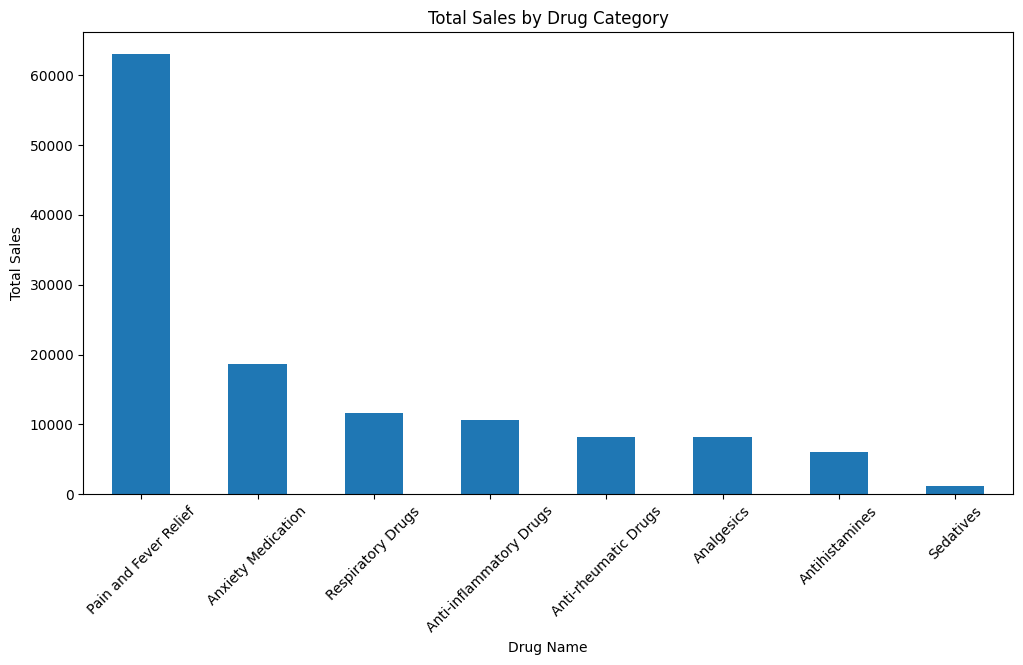

In [25]:
# Visualizing Total Sales by Drug
total_sales_by_drug.plot(kind='bar', figsize=(12,6))
plt.title('Total Sales by Drug Category')
plt.xlabel('Drug Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [26]:
# Peak Sales by Weekday
weekday_sales = sales_daily_long.groupby('day_name')['sales'].sum().sort_values(ascending=False)
print(weekday_sales)

day_name
Saturday     19767.594417
Sunday       18401.437250
Monday       18242.816667
Friday       18134.491583
Tuesday      18065.247000
Wednesday    17771.527500
Thursday     17212.389271
Name: sales, dtype: float64


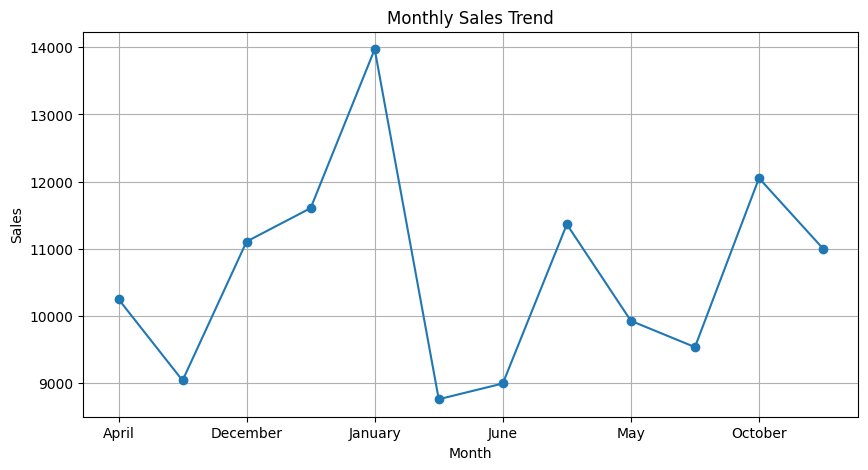

In [27]:
# Monthly Sales Trend
monthly_sales_trend = sales_daily_long.groupby('month_name')['sales'].sum()

monthly_sales_trend.plot(figsize=(10,5), marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

## Database Integration (SQLite)

This section involves connecting to an SQLite database and inserting the processed DataFrames into separate tables. This allows for powerful SQL-based business analysis queries.

In [28]:
# Connecting to SQLite Database
conn = sqlite3.connect('pharma_sales.db')
cursor = conn.cursor()

print('Successfully connected to SQLite database!')

Successfully connected to SQLite database!


In [29]:
# Inserting DataFrames into SQLite Tables
sales_daily_long.to_sql('sales_daily', conn, if_exists='replace', index=False)
print("DataFrame 'sales_daily_long' successfully inserted into 'sales_daily' table.")

sales_hourly_long.to_sql('sales_hourly', conn, if_exists='replace', index=False)
print("DataFrame 'sales_hourly_long' successfully inserted into 'sales_hourly' table.")

sales_weekly_long.to_sql('sales_weekly', conn, if_exists='replace', index=False)
print("DataFrame 'sales_weekly_long' successfully inserted into 'sales_weekly' table.")

sales_monthly_long.to_sql('sales_monthly', conn, if_exists='replace', index=False)
print("DataFrame 'sales_monthly_long' successfully inserted into 'sales_monthly' table.")

DataFrame 'sales_daily_long' successfully inserted into 'sales_daily' table.
DataFrame 'sales_hourly_long' successfully inserted into 'sales_hourly' table.
DataFrame 'sales_weekly_long' successfully inserted into 'sales_weekly' table.
DataFrame 'sales_monthly_long' successfully inserted into 'sales_monthly' table.


In [30]:
# Verifying Inserted Data
cursor.execute("SELECT * FROM sales_daily LIMIT 5")

rows = cursor.fetchall()

print("\n--- First 5 rows from 'sales_daily' table ---")
for row in rows:
  print(row)


--- First 5 rows from 'sales_daily' table ---
('2014-01-02 08:00:00', 2014, 1, 8, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 09:00:00', 2014, 1, 9, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 10:00:00', 2014, 1, 10, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 11:00:00', 2014, 1, 11, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 12:00:00', 2014, 1, 12, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)


**SQL Business Analysis Queries**

## Query 1: Total Sales Across All Drug Categories

In [32]:
# Connecting to SQLite Database

import sqlite3

conn = sqlite3.connect('pharma_sales.db')
cursor = conn.cursor()

print("Successfully connected to SQLite database!")

# Inserting Processed DataFrames into SQLite Tables

sales_daily_long.to_sql(
    'sales_daily',
    conn,
    if_exists='replace',
    index=False
)

print("DataFrame 'sales_daily_long' successfully inserted into 'sales_daily' table.")

sales_hourly_long.to_sql(
    'sales_hourly',
    conn,
    if_exists='replace',
    index=False
)

print("DataFrame 'sales_hourly_long' successfully inserted into 'sales_hourly' table.")

sales_weekly_long.to_sql(
    'sales_weekly',
    conn,
    if_exists='replace',
    index=False
)

print("DataFrame 'sales_weekly_long' successfully inserted into 'sales_weekly' table.")

sales_monthly_long.to_sql(
    'sales_monthly',
    conn,
    if_exists='replace',
    index=False
)

print("DataFrame 'sales_monthly_long' successfully inserted into 'sales_monthly' table.")

# Verifying Inserted Data

cursor.execute("SELECT * FROM sales_daily LIMIT 5")

rows = cursor.fetchall()

print("\\n--- First 5 rows from 'sales_daily' table ---")

for row in rows:
    print(row)

Successfully connected to SQLite database!
DataFrame 'sales_daily_long' successfully inserted into 'sales_daily' table.
DataFrame 'sales_hourly_long' successfully inserted into 'sales_hourly' table.
DataFrame 'sales_weekly_long' successfully inserted into 'sales_weekly' table.
DataFrame 'sales_monthly_long' successfully inserted into 'sales_monthly' table.
\n--- First 5 rows from 'sales_daily' table ---
('2014-01-02 08:00:00', 2014, 1, 8, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 09:00:00', 2014, 1, 9, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 10:00:00', 2014, 1, 10, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 11:00:00', 2014, 1, 11, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)
('2014-01-02 12:00:00', 2014, 1, 12, 'Thursday', 'm01ab', 0.0, 'Anti-inflammatory Drugs', 1, 'January', 'Thursday', 0)


In [33]:
## Query 1: Total Sales Across All Drug Categories

query_1 = '''
SELECT
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily;
'''

pd.read_sql(query_1, conn)

## Business Insight

# This KPI represents the total pharmaceutical sales volume across the dataset and serves as the primary business performance indicator.


,total_sales
0,127595.5


## Query 2: Total Sales by Drug Category

In [34]:
## Query 2: Total Sales by Drug Category

query_2 = '''
SELECT
drug_name,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY drug_name
ORDER BY total_sales DESC;
'''

pd.read_sql(query_2, conn)

## Business Insight

# Identifies the highest and lowest performing drug categories based on total sales contribution.


,drug_name,total_sales
0,Pain and Fever Relief,63005.40
1,Anxiety Medication,18645.74
2,Respiratory Drugs,11608.82
3,Anti-inflammatory Drugs,10600.94
4,Anti-rheumatic Drugs,8204.62
5,Analgesics,8172.21
6,Antihistamines,6107.82
7,Sedatives,1249.96


## Query 3: Sales Contribution Percentage by Drug Category

In [35]:
## Query 3: Sales Contribution Percentage by Drug Category

query_3 = '''
SELECT
drug_name,
ROUND(
SUM(sales) * 100.0 /
(SELECT SUM(sales) FROM sales_daily),
2
) AS contribution_percentage
FROM sales_daily
GROUP BY drug_name
ORDER BY contribution_percentage DESC;
'''

pd.read_sql(query_3, conn)

## Business Insight

# Shows the percentage contribution of each drug category to total pharmaceutical sales, helping identify dominant revenue drivers.


,drug_name,contribution_percentage
0,Pain and Fever Relief,49.38
1,Anxiety Medication,14.61
2,Respiratory Drugs,9.10
3,Anti-inflammatory Drugs,8.31
4,Anti-rheumatic Drugs,6.43
5,Analgesics,6.40
6,Antihistamines,4.79
7,Sedatives,0.98


## Query 4: Average Daily Sales by Drug Category

In [36]:
## Query 4: Average Daily Sales by Drug Category

query_4 = '''
SELECT
drug_name,
ROUND(AVG(sales), 2) AS average_daily_sales
FROM sales_daily
GROUP BY drug_name
ORDER BY average_daily_sales DESC;
'''

pd.read_sql(query_4, conn)

## Business Insight

# Helps identify consistently high-performing drug categories based on average daily demand.


,drug_name,average_daily_sales
0,Pain and Fever Relief,1.25
1,Anxiety Medication,0.37
2,Respiratory Drugs,0.23
3,Anti-inflammatory Drugs,0.21
4,Anti-rheumatic Drugs,0.16
5,Analgesics,0.16
6,Antihistamines,0.12
7,Sedatives,0.02


## Query 5: Total Sales by Weekday

In [37]:
## Query 5: Total Sales by Weekday

query_5 = '''
SELECT
day_name,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY day_name
ORDER BY total_sales DESC;
'''

pd.read_sql(query_5, conn)

## Business Insight

# Analyzes customer purchasing behavior across weekdays to identify the strongest sales days.


,day_name,total_sales
0,Saturday,19767.59
1,Sunday,18401.44
2,Monday,18242.82
3,Friday,18134.49
4,Tuesday,18065.25
5,Wednesday,17771.53
6,Thursday,17212.39


## Query 6: Weekend vs Weekday Sales Performance

In [38]:
## Query 6: Weekend vs Weekday Sales Performance

query_6 = '''
SELECT
weekend_flag,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY weekend_flag;
'''

pd.read_sql(query_6, conn)

## Business Insight

# Compares pharmaceutical sales between weekends and weekdays to understand behavioral demand patterns.


,weekend_flag,total_sales
0,0,89426.47
1,1,38169.03


## Query 7: Peak Sales Hours

In [39]:
## Query 7: Peak Sales Hours

query_7 = '''
SELECT
hour,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_hourly
GROUP BY hour
ORDER BY total_sales DESC;
'''

pd.read_sql(query_7, conn)

## Business Insight

# Identifies the hours with the highest pharmaceutical sales activity and customer demand.


,hour,total_sales
0,19,11321.76
1,20,11211.06
2,11,10733.96
3,12,10546.21
4,18,10071.58
5,10,9591.41
6,13,9573.37
7,14,8780.67
8,17,8254.30
9,15,8186.92


## Query 8: Sales Distribution by Time Period

In [40]:
## Query 8: Sales Distribution by Time Period

query_8 = '''
SELECT
sales_period,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_hourly
GROUP BY sales_period
ORDER BY total_sales DESC;
'''

pd.read_sql(query_8, conn)

## Business Insight

# Shows whether sales activity is concentrated during mornings, afternoons, evenings, or nights.


,sales_period,total_sales
0,Afternoon,52718.79
1,Morning,45579.42
2,Evening,29297.30
3,Night,0.00
4,None,0.00


## Query 9: Monthly Sales Trend

In [41]:
## Query 9: Monthly Sales Trend

query_9 = '''
SELECT
strftime('%Y-%m', datum) AS sales_month,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_monthly
GROUP BY sales_month
ORDER BY sales_month;
'''

pd.read_sql(query_9, conn)

## Business Insight

# Tracks monthly pharmaceutical sales trends and highlights seasonality patterns over time.


,sales_month,total_sales
0,2014-01,1821.11
1,2014-02,1974.47
2,2014-03,1606.72
3,2014-04,1429.68
4,2014-05,1506.30
5,2014-06,1390.21
6,2014-07,1332.37
7,2014-08,1499.02
8,2014-09,1814.59
9,2014-10,3146.91


## Query 10: Quarterly Sales Performance

In [42]:
## Query 10: Quarterly Sales Performance

query_10 = '''
SELECT
quarter,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY quarter
ORDER BY quarter;
'''

pd.read_sql(query_10, conn)

## Business Insight

# Analyzes sales performance across quarters to identify stronger and weaker business periods.


,quarter,total_sales
0,1,36938.86
1,2,29167.55
2,3,28796.97
3,4,32692.12


## Query 11: Top 10 Highest Sales Days

In [43]:
## Query 11: Top 10 Highest Sales Days

query_11 = '''
SELECT
datum,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY datum
ORDER BY total_sales DESC
LIMIT 10;
'''

pd.read_sql(query_11, conn)

## Business Insight

# Identifies the dates with the highest pharmaceutical sales activity and unusual demand spikes.


,datum,total_sales
0,2016-12-30 12:00:00,37.00
1,2018-12-02 16:00:00,36.00
2,2016-02-12 20:00:00,34.33
3,2017-10-22 11:00:00,34.00
4,2017-10-01 15:00:00,31.00
5,2015-01-19 19:00:00,31.00
6,2016-01-02 11:00:00,30.88
7,2016-12-30 21:00:00,30.33
8,2018-09-07 08:00:00,29.00
9,2018-01-06 13:00:00,28.20


## Query 12: Lowest Performing Drug Categories

In [44]:
## Query 12: Lowest Performing Drug Categories

query_12 = '''
SELECT
drug_name,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_daily
GROUP BY drug_name
ORDER BY total_sales ASC;
'''

pd.read_sql(query_12, conn)

## Business Insight

# Highlights low-performing drug categories that may require marketing optimization or inventory review.


,drug_name,total_sales
0,Sedatives,1249.96
1,Antihistamines,6107.82
2,Analgesics,8172.21
3,Anti-rheumatic Drugs,8204.62
4,Anti-inflammatory Drugs,10600.94
5,Respiratory Drugs,11608.82
6,Anxiety Medication,18645.74
7,Pain and Fever Relief,63005.40


## Query 13: Highest Selling Drug Category Each Month

In [45]:
## Query 13: Highest Selling Drug Category Each Month

query_13 = '''
WITH monthly_drug_sales AS (
SELECT
strftime('%Y-%m', datum) AS sales_month,
drug_name,
ROUND(SUM(sales), 2) AS total_sales
FROM sales_monthly
GROUP BY sales_month, drug_name
),
ranked_sales AS (
SELECT *,
RANK() OVER(
PARTITION BY sales_month
ORDER BY total_sales DESC
) AS sales_rank
FROM monthly_drug_sales
)
SELECT *
FROM ranked_sales
WHERE sales_rank = 1;
'''

pd.read_sql(query_13, conn)

## Business Insight

# Identifies the best-performing drug category for each month using ranking and window functions.


,sales_month,drug_name,total_sales,sales_rank
0,2014-01,Pain and Fever Relief,878.03,1
1,2014-02,Pain and Fever Relief,1001.90,1
2,2014-03,Pain and Fever Relief,779.28,1
3,2014-04,Pain and Fever Relief,698.50,1
4,2014-05,Pain and Fever Relief,628.78,1
5,2014-06,Pain and Fever Relief,548.23,1
6,2014-07,Pain and Fever Relief,491.90,1
7,2014-08,Pain and Fever Relief,583.85,1
8,2014-09,Pain and Fever Relief,887.82,1
9,2014-10,Pain and Fever Relief,1856.82,1


## Query 14: Running Total of Monthly Sales

In [46]:
## Query 14: Running Total of Monthly Sales

query_14 = '''
SELECT
datum,
ROUND(SUM(sales), 2) AS monthly_sales,
ROUND(
SUM(SUM(sales)) OVER (ORDER BY datum),
2
) AS running_total_sales
FROM sales_monthly
GROUP BY datum
ORDER BY datum;
'''

pd.read_sql(query_14, conn)

## Business Insight

# Tracks cumulative pharmaceutical sales growth over time and helps visualize long-term business performance.


,datum,monthly_sales,running_total_sales
0,2014-01-31 00:00:00,1821.11,1821.11
1,2014-02-28 00:00:00,1974.47,3795.58
2,2014-03-31 00:00:00,1606.72,5402.30
3,2014-04-30 00:00:00,1429.68,6831.98
4,2014-05-31 00:00:00,1506.30,8338.28
5,2014-06-30 00:00:00,1390.21,9728.48
6,2014-07-31 00:00:00,1332.37,11060.85
7,2014-08-31 00:00:00,1499.02,12559.87
8,2014-09-30 00:00:00,1814.59,14374.47
9,2014-10-31 00:00:00,3146.91,17521.37


## Query 15: Average Monthly Sales by Drug Category

In [47]:
## Query 15: Average Monthly Sales by Drug Category

query_15 = '''
SELECT
drug_name,
ROUND(AVG(sales), 2) AS average_monthly_sales
FROM sales_monthly
GROUP BY drug_name
ORDER BY average_monthly_sales DESC;
'''

pd.read_sql(query_15, conn)

## Business Insight

# Measures the average monthly demand for each drug category to identify consistently strong-performing products.


,drug_name,average_monthly_sales
0,Pain and Fever Relief,892.54
1,Anxiety Medication,262.12
2,Respiratory Drugs,167.68
3,Anti-inflammatory Drugs,149.99
4,Anti-rheumatic Drugs,116.51
5,Analgesics,115.02
6,Antihistamines,86.66
7,Sedatives,17.84


Downloading the processed data to feed in power bi

In [49]:
from google.colab import files

files.download('processed_sales_daily.csv')
files.download('processed_sales_hourly.csv')
files.download('processed_sales_weekly.csv')
files.download('processed_sales_monthly.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>